# Анализ временных рядов (Time Series Analysis)
#### Теория анализа временных рядов (Time Series) строится на поиске зависимостей данных от их собственного прошлого. В отличие от классической статистики, здесь наблюдения не являются независимыми.


## 1. Что такое временной ряд (Time Series)?
### Это последовательность измерений, упорядоченных во времени. В отличие от обычных данных, здесь порядок строк имеет критическое значение.
### Временной ряд — это совокупность наблюдений Y_t где t= 0,1,2, ..., n
### Компоненты: Детерминированная компонента: закономерная часть (тренд + сезонность).
### Стохастическая компонента: случайная часть (шум), которую нельзя предсказать точно, но можно описать статистически.

### Главное свойство: Зависимость текущего значения от предыдущих (автокорреляция).
### Типичный формат: [Время (Timestamp)] + [Значение (Target)].

## 2. Математическая модель (Классическая декомпозиция)
### Любой ряд можно представить как сумму (или произведение) нескольких компонентов:
## Y_t=T_t + S_t + C_t + epsilon_t

## 1) Тренд (T_t): Долгосрочное изменение среднего уровня (рост/падение)
## 2) Сезонность (S_t): Циклические колебания с фиксированным периодом (день, неделя, год).
## 3) Циклы (C_t): Долгосрочные волны (например, экономические кризисы раз в 10 лет). Обычно объединяются с трендом.
## 4) Шум/Остатки (epsilon_t): Непредсказуемая случайная величина. В идеальной модели шум должен быть «белым» (математическое ожидание = 0).
## Типы моделей: Аддитивная: Y = T + S  + epsilon_t (амплитуда сезона постоянна).     Мультипликативная: Y = T * S x * epsilon_t  (амплитуда сезона растет вместе с трендом).

## 3. Сглаживание данных (Smoothing)
### Нужно, чтобы «отфильтровать» шум и увидеть истинный тренд (bспользуются для отделения сигнала от шума):
### A. Простое скользящее среднее (Simple Moving Average, SMA): Берем среднее арифметическое последних N точек. Скользящее среднее (Moving Average, MA Это метод «фильтрации» ряда. Мы заменяем каждое значение средним арифметическим из нескольких предыдущих точек. 
### Зачем: Чтобы увидеть тренд, который прячется за мелкими случайными колебаниями (шумом). 
### Как работает: Если окно (window) равно 7 дням, то значение за сегодня — это среднее за последние 7 дней. Завтра окно сдвинется на один день вперед.
### Эффект: График становится плавным, но немного «запаздывает» (сдвигается вправо), так как среднее всегда опирается на прошлое.
#### Минус: Запаздывает на графике.
### B. Экспоненциальное сглаживание (SES): Новым данным присваивается больший вес, чем старым. Это позволяет модели быстрее реагировать на изменения. Метод Хольта-Уинтерса: Учитывает и уровень, и тренд, и сезонность, придавая больший вес последним значениям.



## 4. Корреляционный анализ
### Это «сердце» анализа временных рядов.
### Автокорреляция (ACF): Корреляция ряда с самим собой, но со сдвигом во времени (лагом).
#### Зачем: Если на лаге 7 (дней) высокий пик — значит, в данных есть недельная сезонность.
### Частичная автокорреляция (PACF): Очищает прямую связь между текущим значением и лагом от влияния промежуточных значений.
#### Зачем: Помогает определить порядок моделей прогнозирования (например, AR в моделях ARIMA).
### AR (AutoRegressive): Текущее значение — это линейная комбинация предыдущих значений.
### MA (Moving Average): Текущее значение — это линейная комбинация прошлых ошибок (шума).
### ARIMA: Объединяет авторегрессию, скользящее среднее и интегрирование (взятие разностей для стационарности).

## 5. Важное понятие: Стационарность
### Ряд называется стационарным, если его статистические свойства (среднее значение, дисперсия) не меняются со временем.
### Большинство методов прогнозирования работают только со стационарными рядами.
### Как сделать ряд стационарным? Убрать тренд (взять разности между соседними точками: Y_t - Y_t-1).

C:\Users\Yerbol Aldanov\AppData\Local\Temp\ipykernel_17792\4036959159.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),


<Figure size 1000x600 with 0 Axes>

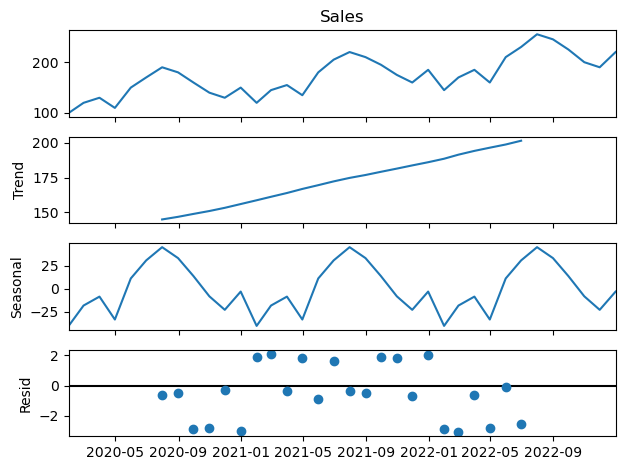

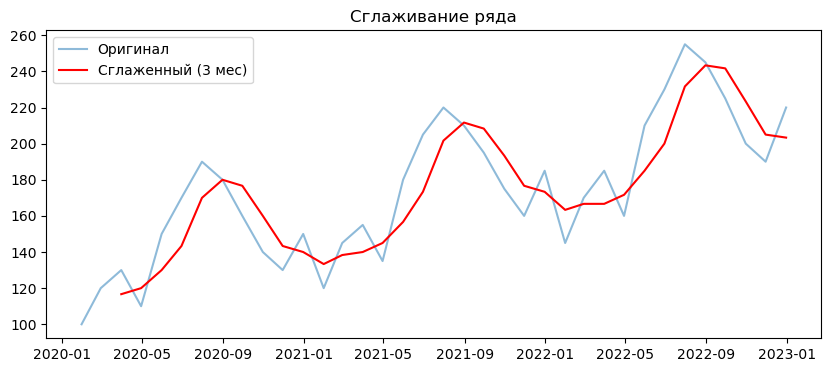

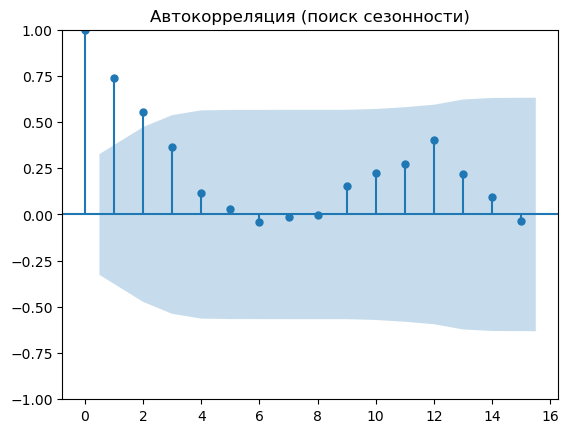

Прогноз на следующий месяц: 203.33


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# --- ШАГ 1: Загрузка и подготовка ---
# Создадим синтетические данные (или загрузим реальные)
data = {
    'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
    'Sales': [100, 120, 130, 110, 150, 170, 190, 180, 160, 140, 130, 150,
              120, 145, 155, 135, 180, 205, 220, 210, 195, 175, 160, 185,
              145, 170, 185, 160, 210, 230, 255, 245, 225, 200, 190, 220]
}
df = pd.DataFrame(data).set_index('Month')

# --- ШАГ 2: Визуализация и декомпозиция ---
plt.figure(figsize=(10, 6))
decomposition = seasonal_decompose(df['Sales'], model='additive')
decomposition.plot()
plt.show()

# --- ШАГ 3: Сглаживание (Moving Average) ---
# Окно 3 месяца, чтобы убрать мелкие колебания
df['SMA_3'] = df['Sales'].rolling(window=3).mean()

plt.figure(figsize=(10, 4))
plt.plot(df['Sales'], label='Оригинал', alpha=0.5)
plt.plot(df['SMA_3'], label='Сглаженный (3 мес)', color='red')
plt.legend()
plt.title('Сглаживание ряда')
plt.show()

# --- ШАГ 4: Корреляционный анализ (ACF) ---
# Ищем повторяющиеся паттерны
plot_acf(df['Sales'], lags=15)
plt.title('Автокорреляция (поиск сезонности)')
plt.show()

# --- ШАГ 5: Базовое прогнозирование (Наивный метод) ---
# Допустим, прогноз на следующий месяц равен среднему за последние 3 месяца
last_value = df['SMA_3'].iloc[-1]
print(f"Прогноз на следующий месяц: {last_value:.2f}")

# Тема лекции: Анализ временных рядов (продолжение).

## 1. Проверка на стационарность (Тест Дики-Фуллера)
### Большинство серьезных моделей (типа ARIMA) работают только со стационарными рядами (где среднее и дисперсия не меняются со временем).
### Что делать: Используйте adfuller из statsmodels.
### Если ряд не стационарен: Нужно брать разности ряда (df.diff()) до тех пор, пока p-value не станет < 0.05.

## 2. Углубленная декомпозиция (STL)
### Вместо обычного seasonal_decompose (который часто дает пропуски по краям и плохо справляется с аномалиями), используйте STL (Seasonal-Trend decomposition using LOESS).
### -Плюс: Она более гибкая, позволяет сезонности меняться во времени и лучше обрабатывает выбросы.
### -Код: from statsmodels.tsa.seasonal import STL.


## 3. Автокорреляция и частичная автокорреляция (ACF / PACF)
### Это «рентген» временного ряда.
### -ACF (Auto-Correlation Function): Помогает найти период сезонности.
### -PACF (Partial Auto-Correlation Function): Помогает определить порядок модели авторегрессии (сколько прошлых шагов реально влияют на текущий, исключая косвенное влияние).
### -Визуализация: from statsmodels.graphics.tsaplots import plot_acf, plot_pacf.


## Этап 1: Предобработка и проверка на стационарность (Тест Дики-Фуллера)
### Большинство моделей прогнозирования требуют, чтобы ряд был стационарным (его статистические свойства не менялись со временем). Если есть тренд — ряд не стационарен.
### 1 Задача: Проверить гипотезу о наличии единичного корня.
### 2 Метод: adfuller из библиотеки statsmodels.
### 3 Логика: Если p-value < 0.05, ряд стационарен. Если больше — нужно брать разности (df.diff()), пока ряд не «успокоится».

## Этап 2: Продвинутая декомпозиция (STL)
### Обычная декомпозиция часто «съедает» данные по краям. STL (Seasonal-Trend decomposition using LOESS) использует локальную регрессию, что позволяет точнее отделить сезонность, даже если она меняется со временем.
### Компоненты:
### Trend: Направление (инфляция, рост популяции).
### -Seasonal: Циклы (день/ночь, зима/лето).
### -Resid (Остатки): То, что нельзя предсказать. Если в остатках видна структура — значит, модель плохая.


## Этап 3: Корреляционный анализ (ACF и PACF)
### Чтобы понять, на сколько шагов назад «смотрит» ваш ряд, строим графики автокорреляции.
### 1 ACF (Автокорреляция): Помогает найти период сезонности (например, пики каждые 12 месяцев).
### 2 PACF (Частная автокорреляция): Показывает прямую зависимость текущего значения от предыдущих, отсекая промежуточное влияние. Это критично для настройки параметров моделей типа ARIMA.


## Этап 4: Построение модели (Holt-Winters или SARIMA)
### Для углубленного уровня лучше всего подходит Тройное экспоненциальное сглаживание (Холт-Уинтерс). Оно учитывает:
### 1 Уровень (текущее значение).
### 2 Тренд (наклон линии).
### 3 Сезонность (цикличность)

## Этап 5: Оценка качества (Backtesting)
### Нельзя просто верить графику. Нужно посчитать метрики:
### 1 MAE: Средняя абсолютная ошибка (показывает отклонение в единицах измерения).
### 2 MAPE: Средняя ошибка в процентах (показывает относительную точность, например, «ошибка 5%»).


# Пример реализации на Python (углубленный):

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Загрузка (важно указать частоту)
df = pd.read_csv('data.csv', index_col='date', parse_dates=True)
df = df.asfreq('D') # Допустим, данные по дням

# 2. Тест на стационарность
result = adfuller(df['target'])
print(f'p-value: {result[1]}') # Если > 0.05, ряд нужно дифференцировать

# 3. STL Декомпозиция
stl = STL(df['target'], seasonal=13).fit()
stl.plot()
plt.show()

# 4. Прогноз методом Холта-Уинтерса
model = ExponentialSmoothing(df['target'], trend='add', seasonal='add', seasonal_periods=7)
fit = model.fit()
forecast = fit.forecast(30) # Прогноз на месяц вперед

# 5. Визуализация результата
plt.figure(figsize=(10,5))
plt.plot(df['target'], label='История')
plt.plot(forecast, label='Прогноз', color='red')
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'